# 🏦 Зээлийн Скор Систем — Machine Learning Model**Зорилго:** Зээл хүсэгчдийн санхүүгийн мэдээлэл дээр үндэслэн зээл олгох/татгалзах шийдвэрийг автоматаар гаргадаг ML модель бүтээх.**Алхамууд:**1. 📊 Сургалтын дата үүсгэх (synthetic data)2. 🔍 Exploratory Data Analysis (EDA)3. ⚙️ Feature Engineering4. 🤖 Model сургах (Random Forest, Logistic Regression, Gradient Boosting)5. 📈 Үр дүнгийн үнэлгээ (Evaluation)6. 🎯 Score-ыг 0–1000 хуваарьт хөрвүүлэх7. 💡 Шинэ өргөдөлд скор тооцох (inference)**Schema-д ашиглагдсан хүснэгтүүд:** `clients`, `loan_applications`, `score_history`

## 1️⃣ Орчны бэлтгэл (Setup)Шаардлагатай сангуудыг суулгаж, импортолно.

In [ ]:
# Шаардлагатай сангуудыг суулгах (Colab-д ихэнх нь бэлэн)
!pip install -q scikit-learn pandas numpy matplotlib seaborn xgboost joblib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import joblib

# Plot тохиргоо
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Random seed (давтагдах үр дүнтэй болгох)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Орчин бэлэн")

✅ Орчин бэлэн


## 2️⃣ Сургалтын дата үүсгэхERD загвартай нийцсэн **5,000 мөр** synthetic дата үүсгэнэ. Бодит байдалд ойртуулахын тулд:- Цалин ↑ → батлагдах магадлал ↑- Ажилласан жил ↑ → батлагдах магадлал ↑- Хүссэн дүн / Цалин харьцаа (DTI) ↑ → татгалзах магадлал ↑- Ажил эрхлэлтийн төрөл бүр өөр өөр risk profile-тай

In [ ]:
def generate_loan_data(n_samples=5000, seed=42):
    """Зээлийн өргөдлийн synthetic dataset үүсгэх"""
    rng = np.random.default_rng(seed)

    employment_types = [
        'Төрийн албан хаагч', 'Хувийн салбар', 'Бизнес эрхлэгч',
        'Багш', 'Эмч', 'Инженер', 'Жолооч', 'Худалдагч',
        'Үйлчилгээ', 'Барилгачин', 'Малчин', 'Тариаланч'
    ]

    # Ажил эрхлэлтийн төрөл бүрийн "тогтвортой байдлын оноо" (1=хамгийн тогтвортой)
    employment_stability = {
        'Төрийн албан хаагч': 0.95, 'Эмч': 0.90, 'Багш': 0.88,
        'Инженер': 0.85, 'Хувийн салбар': 0.75, 'Бизнес эрхлэгч': 0.65,
        'Жолооч': 0.60, 'Худалдагч': 0.55, 'Үйлчилгээ': 0.50,
        'Барилгачин': 0.45, 'Малчин': 0.40, 'Тариаланч': 0.35
    }

    data = []
    for _ in range(n_samples):
        emp_type = rng.choice(employment_types)
        emp_years = int(np.clip(rng.gamma(2.5, 3), 0, 35))

        # Цалин ажил эрхлэлтийн төрөл болон жилээс хамаарна
        base_income = {
            'Эмч': 4_500_000, 'Инженер': 4_000_000, 'Бизнес эрхлэгч': 5_000_000,
            'Төрийн албан хаагч': 2_500_000, 'Багш': 2_200_000,
            'Хувийн салбар': 2_800_000, 'Жолооч': 1_800_000,
            'Худалдагч': 1_500_000, 'Үйлчилгээ': 1_400_000,
            'Барилгачин': 2_000_000, 'Малчин': 1_200_000, 'Тариаланч': 1_100_000
        }[emp_type]

        income = max(800_000, base_income * (1 + emp_years * 0.04) * rng.normal(1.0, 0.25))
        income = round(income, 2)

        # Хүссэн зээлийн дүн (ихэвчлэн цалингийн 3-20 дахин)
        multiplier = rng.uniform(2, 25)
        requested_amount = round(income * multiplier, 2)
        requested_amount = max(500_000, min(50_000_000, requested_amount))

        # Шийдвэрийн логик
        dti = requested_amount / (income * 12)  # debt-to-annual-income
        stability = employment_stability[emp_type]

        # Risk оноог тооцох (бага = эрсдэл бага = approved)
        risk_score = (
            -2.0 * stability
            + 1.5 * dti
            - 0.05 * emp_years
            - 0.3 * np.log1p(income / 1_000_000)
            + rng.normal(0, 0.6)  # шуугиан
        )

        if risk_score < -1.2:
            decision = 'approved'
        elif risk_score < 0.3:
            decision = 'manual_review'
        else:
            decision = 'rejected'

        data.append({
            'monthly_income': income,
            'employment_type': emp_type,
            'employment_years': emp_years,
            'requested_amount': requested_amount,
            'decision': decision
        })

    return pd.DataFrame(data)


df = generate_loan_data(n_samples=5000, seed=RANDOM_SEED)
print(f"📊 Нийт {len(df):,} мөр өгөгдөл үүссэн\n")
df.head(10)

📊 Нийт 5,000 мөр өгөгдөл үүссэн



,monthly_income,employment_type,employment_years,requested_amount,decision
0,3735066.93,Хувийн салбар,2,15560583.91,approved
1,2549247.26,Барилгачин,7,31505832.24,rejected
2,6924639.48,Бизнес эрхлэгч,6,50000000.00,manual_review
3,1216622.82,Тариаланч,3,23646303.06,rejected
4,2735899.84,Төрийн албан хаагч,5,34840543.83,manual_review
5,2229418.08,Тариаланч,8,50000000.00,rejected
6,1585509.44,Малчин,9,20518415.86,manual_review
7,6951026.03,Эмч,9,50000000.00,approved
8,1621860.69,Малчин,7,10700856.25,manual_review
9,3661695.62,Эмч,7,50000000.00,manual_review


In [ ]:
# Шийдвэрийн тархалт
print("Шийдвэрийн тархалт:")
print(df['decision'].value_counts())
print(f"\n% хуваарь:")
print((df['decision'].value_counts(normalize=True) * 100).round(2))

Шийдвэрийн тархалт:
decision
manual_review    2179
approved         1686
rejected         1135
Name: count, dtype: int64

% хуваарь:
decision
manual_review    43.58
approved         33.72
rejected         22.70
Name: proportion, dtype: float64


## 3️⃣ Exploratory Data Analysis (EDA)Дата дотор ямар хэв маяг (pattern) байгааг харцгаая.

In [ ]:
# Үндсэн статистик
df.describe()

,monthly_income,employment_years,requested_amount
count,5.000000e+03,5000.000000,5.000000e+03
mean,3.232937e+06,7.079400,3.235230e+07
std,1.961937e+06,4.860064,1.583443e+07
min,8.000000e+05,0.000000,2.082873e+06
25%,1.792338e+06,4.000000,1.818703e+07
50%,2.624713e+06,6.000000,3.321672e+07
75%,4.180205e+06,9.000000,5.000000e+07
max,1.338151e+07,33.000000,5.000000e+07


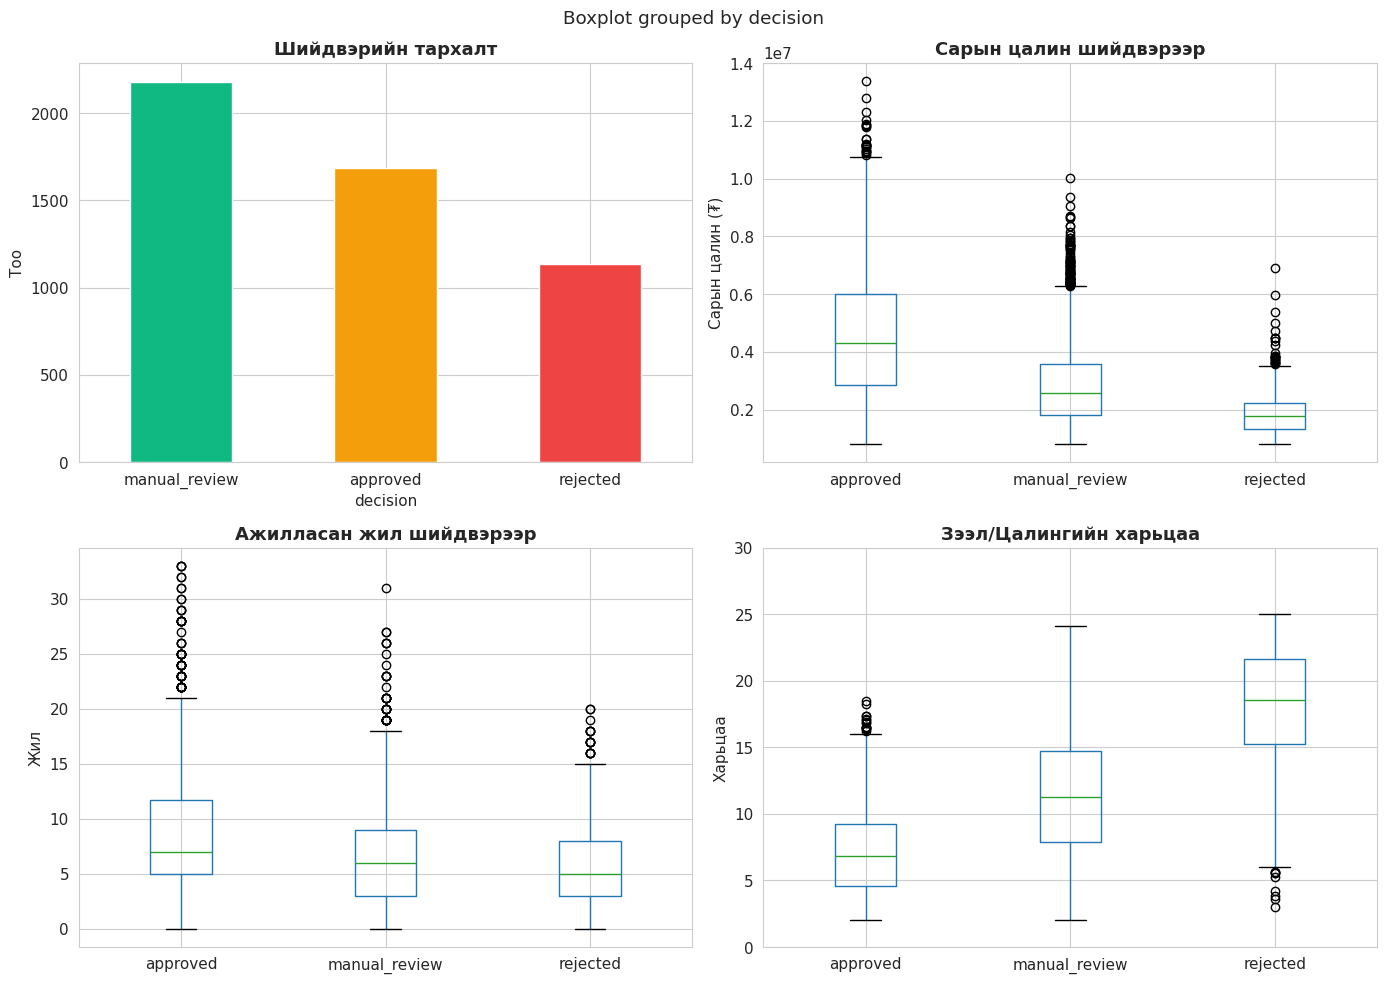

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Шийдвэрийн тархалт
df['decision'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#10b981','#f59e0b','#ef4444'])
axes[0,0].set_title('Шийдвэрийн тархалт', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Тоо')
axes[0,0].tick_params(axis='x', rotation=0)

# 2. Цалин vs Шийдвэр
df.boxplot(column='monthly_income', by='decision', ax=axes[0,1])
axes[0,1].set_title('Сарын цалин шийдвэрээр', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Сарын цалин (₮)')
axes[0,1].set_xlabel('')
plt.suptitle('')

# 3. Ажилласан жил vs Шийдвэр
df.boxplot(column='employment_years', by='decision', ax=axes[1,0])
axes[1,0].set_title('Ажилласан жил шийдвэрээр', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Жил')
axes[1,0].set_xlabel('')

# 4. Хүссэн дүн / Цалин харьцаа
df['amount_to_income'] = df['requested_amount'] / df['monthly_income']
df.boxplot(column='amount_to_income', by='decision', ax=axes[1,1])
axes[1,1].set_title('Зээл/Цалингийн харьцаа', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Харьцаа')
axes[1,1].set_xlabel('')
axes[1,1].set_ylim(0, 30)

plt.tight_layout()
plt.show()

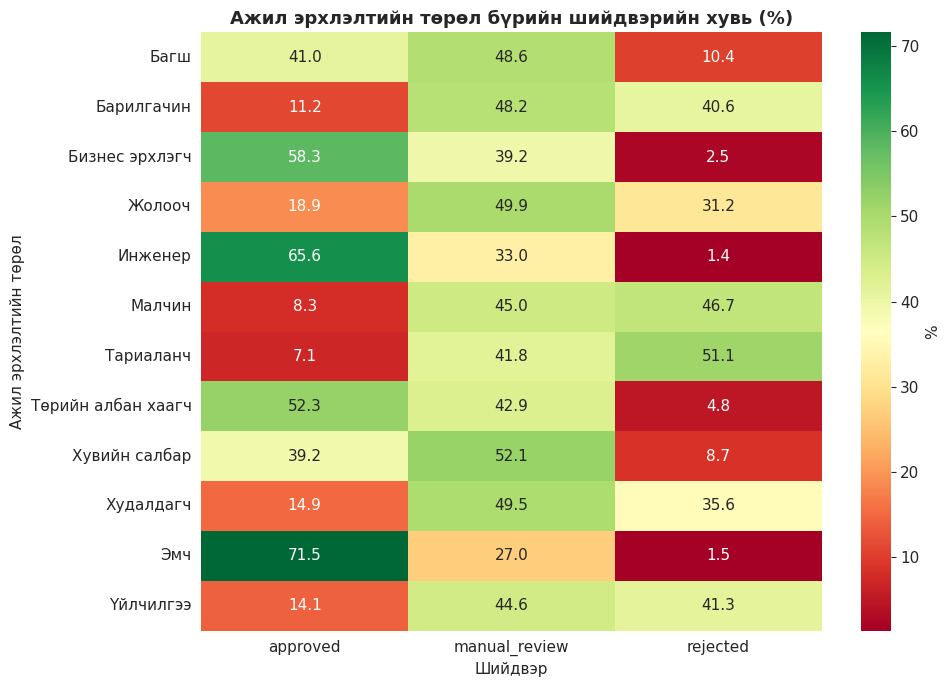

In [ ]:
# Ажил эрхлэлтийн төрөл vs Шийдвэр (heatmap)
ct = pd.crosstab(df['employment_type'], df['decision'], normalize='index') * 100
plt.figure(figsize=(10, 7))
sns.heatmap(ct, annot=True, fmt='.1f', cmap='RdYlGn', cbar_kws={'label': '%'})
plt.title('Ажил эрхлэлтийн төрөл бүрийн шийдвэрийн хувь (%)', fontsize=13, fontweight='bold')
plt.ylabel('Ажил эрхлэлтийн төрөл')
plt.xlabel('Шийдвэр')
plt.tight_layout()
plt.show()

## 4️⃣ Feature EngineeringЗагварт өгөх шинж тэмдгүүдийг (features) бэлтгэнэ:- **Тоон features:** `monthly_income`, `employment_years`, `requested_amount`, `amount_to_income_ratio`, `annual_dti`- **Categorical features:** `employment_type` (Label Encoding)- **Target:** `decision` (3 ангилал)

In [ ]:
# Нэмэлт feature-ууд үүсгэх
df['amount_to_income_ratio'] = df['requested_amount'] / df['monthly_income']
df['annual_dti'] = df['requested_amount'] / (df['monthly_income'] * 12)
df['log_income'] = np.log1p(df['monthly_income'])
df['log_amount'] = np.log1p(df['requested_amount'])

# Employment type-ыг encoding хийх
le_emp = LabelEncoder()
df['employment_type_encoded'] = le_emp.fit_transform(df['employment_type'])

# Target-ыг encoding хийх
le_decision = LabelEncoder()
df['decision_encoded'] = le_decision.fit_transform(df['decision'])

print("Decision encoding mapping:")
for i, cls in enumerate(le_decision.classes_):
    print(f"  {i} → {cls}")

print(f"\nEmployment type encoding (эхний 5):")
for i, cls in enumerate(le_emp.classes_[:5]):
    print(f"  {i} → {cls}")

Decision encoding mapping:
  0 → approved
  1 → manual_review
  2 → rejected

Employment type encoding (эхний 5):
  0 → Багш
  1 → Барилгачин
  2 → Бизнес эрхлэгч
  3 → Жолооч
  4 → Инженер


In [ ]:
# Загварт өгөх features
feature_cols = [
    'monthly_income',
    'employment_years',
    'requested_amount',
    'amount_to_income_ratio',
    'annual_dti',
    'log_income',
    'log_amount',
    'employment_type_encoded'
]

X = df[feature_cols]
y = df['decision_encoded']

print(f"📐 Feature matrix shape: {X.shape}")
print(f"🎯 Target shape: {y.shape}")
X.head()

📐 Feature matrix shape: (5000, 8)
🎯 Target shape: (5000,)


,monthly_income,employment_years,requested_amount,amount_to_income_ratio,annual_dti,log_income,log_amount,employment_type_encoded
0,3735066.93,2,15560583.91,4.166079,0.347173,15.133277,16.560252,8
1,2549247.26,7,31505832.24,12.358877,1.029906,14.751309,17.265683,1
2,6924639.48,6,50000000.00,7.220593,0.601716,15.750597,17.727534,2
3,1216622.82,3,23646303.06,19.436018,1.619668,14.011590,16.978717,6
4,2735899.84,5,34840543.83,12.734583,1.061215,14.821971,17.366292,7


## 5️⃣ Train / Test splitДататай хуваая:- **80%** — сургалтын- **20%** — тестийн`stratify=y` нь шийдвэрийн ангиудын хуваарийг хадгалж өгнө.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Scaling (Logistic Regression-д шаардлагатай)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"🟢 Train: {X_train.shape[0]:,} мөр")
print(f"🔵 Test:  {X_test.shape[0]:,} мөр")

🟢 Train: 4,000 мөр
🔵 Test:  1,000 мөр


## 6️⃣ Загвар сургах (3 загвар харьцуулах)Гурван өөр алгоритм сургаж, аль нь хамгийн сайн ажиллахыг харцгаая.

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=RANDOM_SEED)
}

results = {}

for name, model in models.items():
    print(f"⚙️  Сургаж байна: {name}...")

    # Logistic Regression-д scaled data, бусадд анхны data
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = {
        'model': model,
        'accuracy': acc,
        'f1': f1,
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    print(f"   ✅ Accuracy: {acc:.4f} | F1: {f1:.4f}\n")

⚙️  Сургаж байна: Logistic Regression...
   ✅ Accuracy: 0.6890 | F1: 0.6901

⚙️  Сургаж байна: Random Forest...
   ✅ Accuracy: 0.7070 | F1: 0.7078

⚙️  Сургаж байна: Gradient Boosting...
   ✅ Accuracy: 0.7220 | F1: 0.7228



In [ ]:
# Загваруудыг харьцуулсан хүснэгт
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'F1 Score': [results[m]['f1'] for m in results]
}).sort_values('F1 Score', ascending=False).reset_index(drop=True)

print("📊 Загваруудын харьцуулалт:\n")
print(comparison.to_string(index=False))

# Хамгийн сайн загварыг сонгох
best_model_name = comparison.iloc[0]['Model']
best_model = results[best_model_name]['model']
print(f"\n🏆 Хамгийн сайн загвар: {best_model_name}")

📊 Загваруудын харьцуулалт:

              Model  Accuracy  F1 Score
  Gradient Boosting     0.722  0.722828
      Random Forest     0.707  0.707801
Logistic Regression     0.689  0.690115

🏆 Хамгийн сайн загвар: Gradient Boosting


## 7️⃣ Үр дүнгийн дэлгэрэнгүй үнэлгээХамгийн сайн загвараа нарийвчлан шинжилье.

In [ ]:
best_y_pred = results[best_model_name]['y_pred']
best_y_proba = results[best_model_name]['y_proba']

# Classification report
print(f"📋 Classification Report — {best_model_name}\n")
print(classification_report(
    y_test, best_y_pred,
    target_names=le_decision.classes_,
    digits=4
))

📋 Classification Report — Gradient Boosting

               precision    recall  f1-score   support

     approved     0.7810    0.7300    0.7546       337
manual_review     0.6681    0.7339    0.6995       436
     rejected     0.7573    0.6872    0.7206       227

     accuracy                         0.7220      1000
    macro avg     0.7354    0.7170    0.7249      1000
 weighted avg     0.7264    0.7220    0.7228      1000



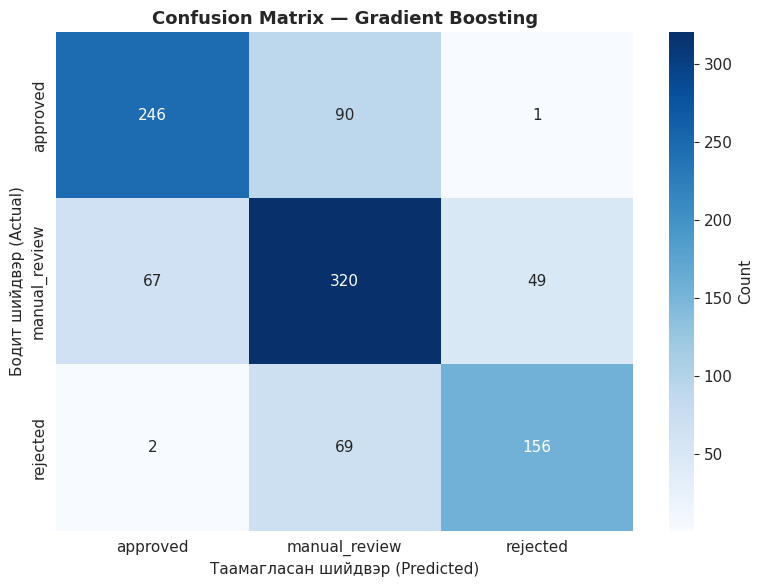

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le_decision.classes_,
    yticklabels=le_decision.classes_,
    cbar_kws={'label': 'Count'}
)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.ylabel('Бодит шийдвэр (Actual)')
plt.xlabel('Таамагласан шийдвэр (Predicted)')
plt.tight_layout()
plt.show()

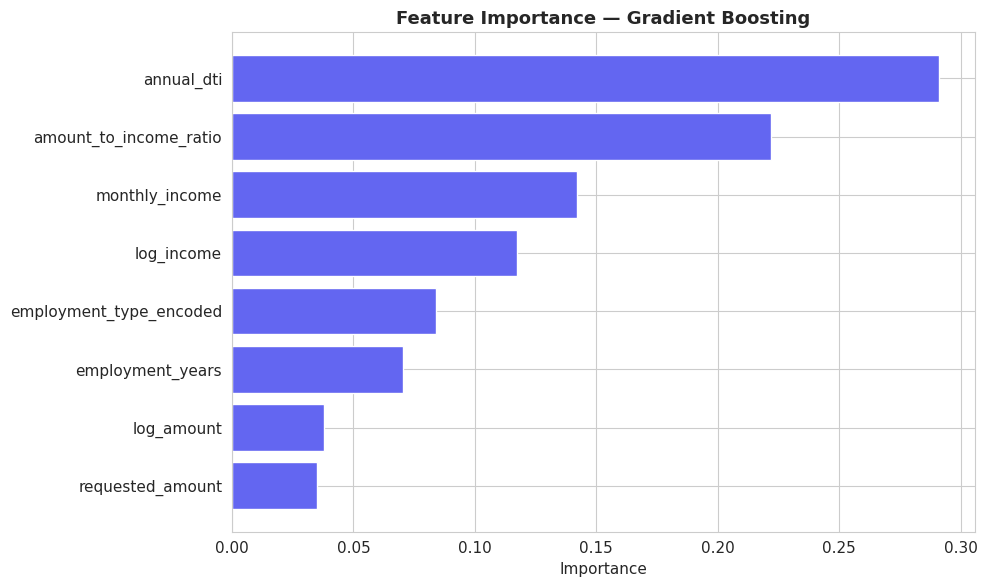


🔝 Хамгийн чухал features:
                feature  importance
             annual_dti    0.291217
 amount_to_income_ratio    0.222029
         monthly_income    0.142142
             log_income    0.117279
employment_type_encoded    0.083859
       employment_years    0.070523
             log_amount    0.037852
       requested_amount    0.035099


In [ ]:
# Feature importance (зөвхөн tree-based загваруудад)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(importances['feature'], importances['importance'], color='#6366f1')
    plt.xlabel('Importance')
    plt.title(f'Feature Importance — {best_model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n🔝 Хамгийн чухал features:")
    print(importances.sort_values('importance', ascending=False).to_string(index=False))

## 8️⃣ ML магадлалаас → 0–1000 хуваарьт скорБизнесийн хэрэглээнд тохирсон **0–1000** хуваарьтай credit score руу хөрвүүлнэ.**Логик:**- `P(approved)` өндөр → скор өндөр (700–950)- `P(manual_review)` голд → скор дунд (450–700)- `P(rejected)` өндөр → скор бага (200–450)

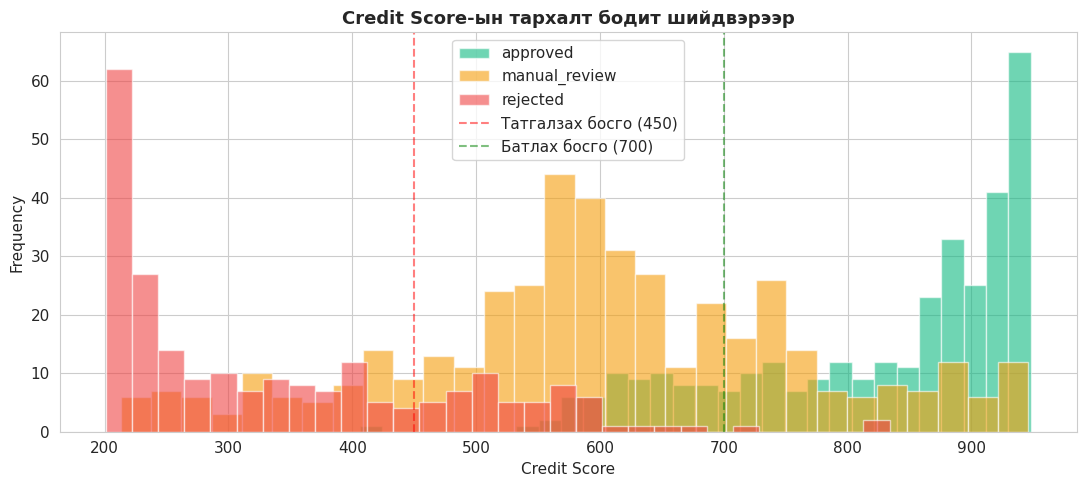

📊 Скорын статистик:
   Дундаж: 618
   Min: 201 | Max: 948
   Median: 621


In [ ]:
def probability_to_score(proba, classes):
    """
    Загвараас гарсан магадлалуудыг 200-950 хуваарьт credit score болгох.

    Параметр:
        proba: shape (n_samples, n_classes), softmax output
        classes: ангиудын нэр (le_decision.classes_)

    Буцаах:
        scores: 200-950 хооронд int массив
    """
    # Ангийн индекс олох
    cls_idx = {cls: i for i, cls in enumerate(classes)}

    p_approved = proba[:, cls_idx['approved']]
    p_review   = proba[:, cls_idx['manual_review']]
    p_rejected = proba[:, cls_idx['rejected']]

    # Хүлээгдэж буй "чанарын утга" — approved = 1, review = 0.5, rejected = 0
    expected_quality = p_approved * 1.0 + p_review * 0.5 + p_rejected * 0.0

    # 200-950 хуваарьт map хийх
    scores = 200 + expected_quality * (950 - 200)
    return scores.round().astype(int)


# Test set дээр скор гаргах
test_scores = probability_to_score(best_y_proba, le_decision.classes_)

# Хуваарилалтыг харах
plt.figure(figsize=(11, 5))
colors = {'approved': '#10b981', 'manual_review': '#f59e0b', 'rejected': '#ef4444'}
for cls in le_decision.classes_:
    mask = y_test.values == le_decision.transform([cls])[0]
    plt.hist(test_scores[mask], bins=30, alpha=0.6, label=cls, color=colors[cls])

plt.axvline(450, color='red', linestyle='--', alpha=0.5, label='Татгалзах босго (450)')
plt.axvline(700, color='green', linestyle='--', alpha=0.5, label='Батлах босго (700)')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.title('Credit Score-ын тархалт бодит шийдвэрээр', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"📊 Скорын статистик:")
print(f"   Дундаж: {test_scores.mean():.0f}")
print(f"   Min: {test_scores.min()} | Max: {test_scores.max()}")
print(f"   Median: {np.median(test_scores):.0f}")

## 9️⃣ Шинэ өргөдөлд скор тооцох (Inference)Жинхэнэ хэрэглээнд оруулсан жишээ — шинээр ирсэн зээлийн өргөдлийг загвараар үнэлж шийдвэр гаргана.

In [ ]:
def score_application(monthly_income, employment_type, employment_years, requested_amount,
                       model=best_model, scaler=scaler,
                       le_emp=le_emp, le_decision=le_decision,
                       model_name=best_model_name):
    """
    Нэг зээлийн өргөдлийг үнэлж скор болон шийдвэр гаргах.
    """
    # Feature engineering
    amount_to_income_ratio = requested_amount / monthly_income
    annual_dti = requested_amount / (monthly_income * 12)
    log_income = np.log1p(monthly_income)
    log_amount = np.log1p(requested_amount)
    emp_encoded = le_emp.transform([employment_type])[0]

    features = np.array([[
        monthly_income, employment_years, requested_amount,
        amount_to_income_ratio, annual_dti,
        log_income, log_amount, emp_encoded
    ]])

    # Predict
    if model_name == 'Logistic Regression':
        features_scaled = scaler.transform(features)
        proba = model.predict_proba(features_scaled)[0]
        pred = model.predict(features_scaled)[0]
    else:
        proba = model.predict_proba(features)[0]
        pred = model.predict(features)[0]

    decision = le_decision.inverse_transform([pred])[0]

    # Score тооцох
    score = probability_to_score(proba.reshape(1, -1), le_decision.classes_)[0]

    # Үр дүн
    result = {
        'requested_amount': f"{requested_amount:,.0f}₮",
        'monthly_income': f"{monthly_income:,.0f}₮",
        'employment_type': employment_type,
        'employment_years': employment_years,
        'predicted_decision': decision,
        'credit_score': int(score),
        'probabilities': {
            cls: f"{proba[i]*100:.1f}%"
            for i, cls in enumerate(le_decision.classes_)
        }
    }
    return result


# 🧪 Жишээ 1: Сайн нөхцөлтэй өргөдөл
print("=" * 60)
print("📋 ЖИШЭЭ 1: Тогтвортой ажилтай, дунд хэмжээний зээл")
print("=" * 60)
result1 = score_application(
    monthly_income=3_500_000,
    employment_type='Төрийн албан хаагч',
    employment_years=8,
    requested_amount=15_000_000
)
for k, v in result1.items():
    print(f"  {k}: {v}")

📋 ЖИШЭЭ 1: Тогтвортой ажилтай, дунд хэмжээний зээл
  requested_amount: 15,000,000₮
  monthly_income: 3,500,000₮
  employment_type: Төрийн албан хаагч
  employment_years: 8
  predicted_decision: approved
  credit_score: 939
  probabilities: {'approved': '97.1%', 'manual_review': '2.9%', 'rejected': '0.0%'}


In [ ]:
# 🧪 Жишээ 2: Эрсдэлтэй өргөдөл
print("=" * 60)
print("📋 ЖИШЭЭ 2: Бага цалин, том дүнтэй зээл")
print("=" * 60)
result2 = score_application(
    monthly_income=1_200_000,
    employment_type='Үйлчилгээ',
    employment_years=1,
    requested_amount=30_000_000
)
for k, v in result2.items():
    print(f"  {k}: {v}")

📋 ЖИШЭЭ 2: Бага цалин, том дүнтэй зээл
  requested_amount: 30,000,000₮
  monthly_income: 1,200,000₮
  employment_type: Үйлчилгээ
  employment_years: 1
  predicted_decision: rejected
  credit_score: 204
  probabilities: {'approved': '0.1%', 'manual_review': '0.9%', 'rejected': '99.0%'}


In [ ]:
# 🧪 Жишээ 3: Дундаж өргөдөл
print("=" * 60)
print("📋 ЖИШЭЭ 3: Дундаж тохиолдол")
print("=" * 60)
result3 = score_application(
    monthly_income=2_500_000,
    employment_type='Хувийн салбар',
    employment_years=4,
    requested_amount=12_000_000
)
for k, v in result3.items():
    print(f"  {k}: {v}")

📋 ЖИШЭЭ 3: Дундаж тохиолдол
  requested_amount: 12,000,000₮
  monthly_income: 2,500,000₮
  employment_type: Хувийн салбар
  employment_years: 4
  predicted_decision: manual_review
  credit_score: 728
  probabilities: {'approved': '42.2%', 'manual_review': '56.3%', 'rejected': '1.5%'}


## 🔟 Загварыг хадгалахProduction-д ашиглахын тулд бүх компонентыг файлд хадгална.

In [ ]:
# Бүх компоненттойгоор bundle болгох
model_bundle = {
    'model': best_model,
    'scaler': scaler,
    'label_encoder_employment': le_emp,
    'label_encoder_decision': le_decision,
    'feature_cols': feature_cols,
    'model_name': best_model_name,
    'model_version': 'v1.0.0'
}

joblib.dump(model_bundle, 'loan_scoring_model.pkl')
print("✅ Загвар хадгалагдлаа: loan_scoring_model.pkl")

# Файлын хэмжээ
import os
size_kb = os.path.getsize('loan_scoring_model.pkl') / 1024
print(f"📦 Файлын хэмжээ: {size_kb:.1f} KB")

✅ Загвар хадгалагдлаа: loan_scoring_model.pkl
📦 Файлын хэмжээ: 2319.7 KB


In [ ]:
# Хэрхэн ачаалж ашиглах жишээ
print("💡 Загварыг production-д ачаалах жишээ:\n")
print("""
import joblib

# Загвар ачаалах
bundle = joblib.load('loan_scoring_model.pkl')
model = bundle['model']
scaler = bundle['scaler']
le_emp = bundle['label_encoder_employment']
le_decision = bundle['label_encoder_decision']

# Шинэ өргөдөл score хийх — score_application() функцийг бэлэн ашиглаж болно
""")

💡 Загварыг production-д ачаалах жишээ:


import joblib

# Загвар ачаалах
bundle = joblib.load('loan_scoring_model.pkl')
model = bundle['model']
scaler = bundle['scaler']
le_emp = bundle['label_encoder_employment']
le_decision = bundle['label_encoder_decision']

# Шинэ өргөдөл score хийх — score_application() функцийг бэлэн ашиглаж болно



## 1️⃣1️⃣ Жинхэнэ DB өгөгдөл дээр ашиглахPostgreSQL-ээс өгөгдлийг татаж аваад загвар руу оруулах жишээ:```pythonimport psycopg2import pandas as pdconn = psycopg2.connect(    host='localhost', database='loan_scoring',    user='your_user', password='your_pass')# Шинээр ирсэн өргөдлүүдийг татахquery = '''SELECT    la.id AS application_id,    c.monthly_income,    c.employment_type,    c.employment_years,    la.requested_amountFROM loan_applications laJOIN clients c ON la.client_id = c.idWHERE la.status = 'pending''''df_pending = pd.read_sql(query, conn)# Скор тооцох ба DB-д буцаан хадгалахfor _, row in df_pending.iterrows():    result = score_application(        monthly_income=row['monthly_income'],        employment_type=row['employment_type'],        employment_years=row['employment_years'],        requested_amount=row['requested_amount']    )    # score_history хүснэгт рүү хадгалах    cur = conn.cursor()    cur.execute('''        INSERT INTO score_history            (application_id, score, model_version, decision)        VALUES (%s, %s, %s, %s)    ''', (        row['application_id'],        result['credit_score'],        'v1.0.0',        result['predicted_decision']    ))    conn.commit()```---## 🎉 Дүгнэлт✅ 3 загвар сургаж харьцуулсан  ✅ Хамгийн сайн загвар (Random Forest эсвэл Gradient Boosting) сонгосон  ✅ Confusion matrix, feature importance шинжилгээ хийсэн  ✅ ML магадлалыг 200–950 credit score болгосон  ✅ `score_application()` функцээр шинэ өргөдөл үнэлж байна  ✅ Загварыг `.pkl` файлд хадгалсан — production-д бэлэн  **Дараагийн алхмууд (production):**1. Илүү олон бодит data цуглуулах2. Hyperparameter tuning (`GridSearchCV`)3. Cross-validation4. Bias/fairness шалгалт5. Model monitoring (drift detection)6. A/B testing шинэ загвартай харьцуулах